In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
deliveries_data = pd.read_csv(r'D:\ipl_resources/IPL Ball-by-Ball 2008-2020.csv')
match_data = pd.read_csv(r'D:\ipl_resources/IPL Matches 2008-2020.csv')

In [9]:
match_data.head(2)

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,NaN,MR Benson,SL Shastri


In [19]:
match_data.shape
match_data.shape[0]        # Total Matches Played

816

In [15]:
deliveries_data.shape

(193468, 18)

In [17]:
type(match_data.shape)

tuple

In [27]:
match_data['city'].unique()                 # Venues Played At

array(['Bangalore', 'Chandigarh', 'Delhi', 'Mumbai', 'Kolkata', 'Jaipur',
       'Hyderabad', 'Chennai', 'Cape Town', 'Port Elizabeth', 'Durban',
       'Centurion', 'East London', 'Johannesburg', 'Kimberley',
       'Bloemfontein', 'Ahmedabad', 'Cuttack', 'Nagpur', 'Dharamsala',
       'Kochi', 'Indore', 'Visakhapatnam', 'Pune', 'Raipur', 'Ranchi',
       'Abu Dhabi', nan, 'Rajkot', 'Kanpur', 'Bengaluru', 'Dubai',
       'Sharjah'], dtype=object)

In [25]:
match_data['team1'].unique()               # Total teams participated

array(['Royal Challengers Bangalore', 'Kings XI Punjab',
       'Delhi Daredevils', 'Mumbai Indians', 'Kolkata Knight Riders',
       'Rajasthan Royals', 'Deccan Chargers', 'Chennai Super Kings',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Gujarat Lions', 'Rising Pune Supergiants',
       'Rising Pune Supergiant', 'Delhi Capitals'], dtype=object)

In [31]:
match_data['toss_winner'].value_counts()
match_data['toss_winner'].value_counts().index[0]

'Mumbai Indians'

In [33]:
match_data['player_of_match'].value_counts().index[0]                   # Most Player of the match

'AB de Villiers'

In [35]:
### Particular batsman analysis:

In [41]:
deliveries_data

,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
0,335982,1,6,5,RT Ponting,BB McCullum,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
1,335982,1,6,6,BB McCullum,RT Ponting,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
2,335982,1,7,1,BB McCullum,RT Ponting,Z Khan,0,0,0,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
3,335982,1,7,2,BB McCullum,RT Ponting,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
4,335982,1,7,3,RT Ponting,BB McCullum,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193463,1237181,1,12,5,RR Pant,SS Iyer,NM Coulter-Nile,0,0,0,0,0,NaN,NaN,NaN,NaN,Delhi Capitals,Mumbai Indians
193464,1237181,1,12,6,RR Pant,SS Iyer,NM Coulter-Nile,1,0,1,0,0,NaN,NaN,NaN,NaN,Delhi Capitals,Mumbai Indians
193465,1237181,1,13,1,RR Pant,SS Iyer,KH Pandya,0,1,1,0,0,NaN,NaN,NaN,wides,Delhi Capitals,Mumbai Indians
193466,1237181,1,13,2,RR Pant,SS Iyer,KH Pandya,1,0,1,0,0,NaN,NaN,NaN,NaN,Delhi Capitals,Mumbai Indians


In [43]:
deliveries_data['batsman'].unique()             # finding the list of all batsman

array(['RT Ponting', 'BB McCullum', 'DJ Hussey', 'Mohammad Hafeez',
       'SC Ganguly', 'CL White', 'MV Boucher', 'B Akhil', 'AA Noffke',
       'P Kumar', 'Z Khan', 'SB Joshi', 'W Jaffer', 'JH Kallis',
       'R Dravid', 'V Kohli', 'K Goel', 'MEK Hussey', 'JR Hopes',
       'SK Raina', 'JDP Oram', 'S Badrinath', 'PA Patel', 'ML Hayden',
       'MS Dhoni', 'KC Sangakkara', 'Yuvraj Singh', 'SM Katich',
       'IK Pathan', 'T Kohli', 'YK Pathan', 'S Dhawan', 'G Gambhir',
       'SK Warne', 'D Salunkhe', 'SK Trivedi', 'V Sehwag', 'SR Watson',
       'M Kaif', 'DS Lehmann', 'RA Jadeja', 'M Rawat', 'L Ronchi',
       'ST Jayasuriya', 'DJ Thornely', 'RV Uthappa', 'PR Shah',
       'AM Nayar', 'SM Pollock', 'Harbhajan Singh', 'S Chanderpaul',
       'LRPL Taylor', 'WP Saha', 'AS Yadav', 'A Symonds', 'SB Bangar',
       'WPUJC Vaas', 'RP Singh', 'AC Gilchrist', 'Y Venugopal Rao',
       'VVS Laxman', 'RG Sharma', 'SB Styris', 'LR Shukla', 'PP Chawla',
       'Kamran Akmal', 'DPMD Jayawardene'

In [51]:
filt = deliveries_data['batsman']=='V Kohli'         # Analysis the data for Virat Kohli (V Kohli)
df_kohli = deliveries_data[filt]
df_kohli.columns

Index(['id', 'inning', 'over', 'ball', 'batsman', 'non_striker', 'bowler',
       'batsman_runs', 'extra_runs', 'total_runs', 'non_boundary', 'is_wicket',
       'dismissal_kind', 'player_dismissed', 'fielder', 'extras_type',
       'batting_team', 'bowling_team'],
      dtype='object')

In [53]:
df_kohli['dismissal_kind'].value_counts()

dismissal_kind
caught               105
bowled                30
run out               15
lbw                    7
stumped                3
caught and bowled      3
Name: count, dtype: int64

In [55]:
df_kohli['batsman_runs'].unique()

array([0, 1, 4, 6, 2, 3], dtype=int64)

In [61]:
a = len(df_kohli[df_kohli['batsman_runs']==1])           # Total runs scored by taking singles ie 1's
a

1919

In [63]:
b = len(df_kohli[df_kohli['batsman_runs']==2])*2             # Total runs scored by taking doubles ie 2's
c = len(df_kohli[df_kohli['batsman_runs']==3])*3             # Total runs scored by taking triples ie 3's
d = len(df_kohli[df_kohli['batsman_runs']==4])*4             # Total runs scored by hitting boundaries ie 4's
e = len(df_kohli[df_kohli['batsman_runs']==6])*6             # Total runs scored by hitting sixes ie 6's

In [65]:
import plotly.express as px
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, plot , iplot 

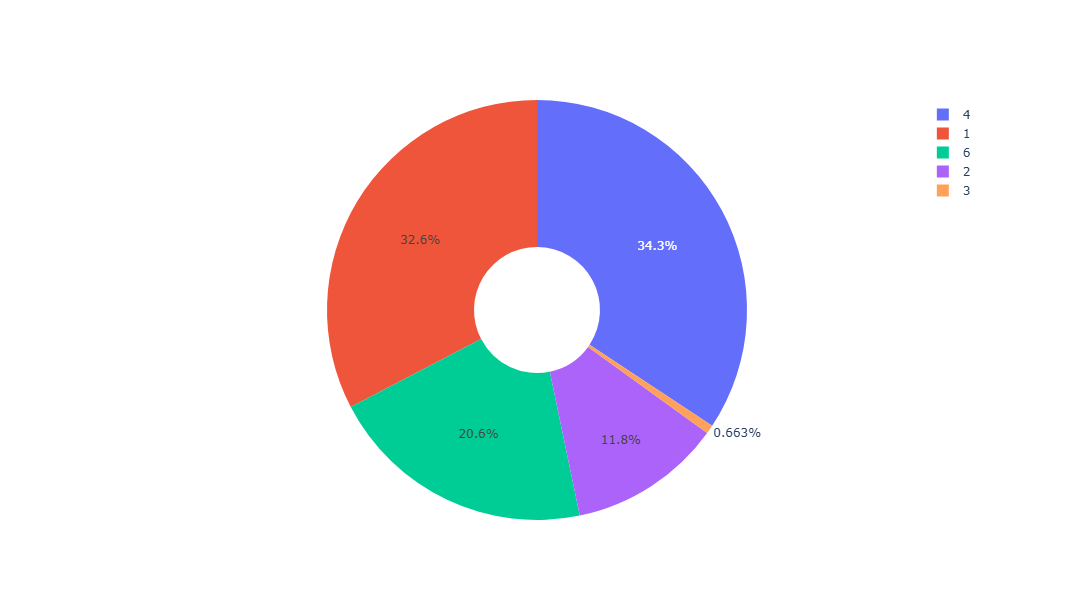

In [71]:
values = [a , b , c , d , e]
run_cat = [1, 2, 3 ,4, 6]

trace = go.Pie(labels= run_cat , values= values , hole=0.3)
data = [trace]
fig = go.Figure(data = data)

fig.update_layout(width=600,height=600)

fig.show()

In [94]:
### Toss decision across seasons

In [96]:
match_data.columns

Index(['id', 'city', 'date', 'player_of_match', 'venue', 'neutral_venue',
       'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result',
       'result_margin', 'eliminator', 'method', 'umpire1', 'umpire2'],
      dtype='object')

In [112]:
match_data['Season'] = pd.to_datetime(match_data['date']).dt.year  # extracting the season from "date" feature

In [114]:
match_data.head(2)

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2,Season
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen,2008
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,NaN,MR Benson,SL Shastri,2008


In [118]:
match_data.groupby(['Season' , 'toss_decision']).size()     # the output is a series

Season  toss_decision
2008    bat              26
        field            32
2009    bat              35
        field            22
2010    bat              39
        field            21
2011    bat              25
        field            48
2012    bat              37
        field            37
2013    bat              45
        field            31
2014    bat              19
        field            41
2015    bat              25
        field            34
2016    bat              11
        field            49
2017    bat              11
        field            48
2018    bat              10
        field            50
2019    bat              10
        field            50
2020    bat              27
        field            33
dtype: int64

In [122]:
season_toss_count_df = match_data.groupby(['Season' , 'toss_decision']).size().reset_index().rename(columns={0:'count'})

## converting the above Series into Dataframe
season_toss_count_df

,Season,toss_decision,count
0,2008,bat,26
1,2008,field,32
2,2009,bat,35
3,2009,field,22
4,2010,bat,39
5,2010,field,21
6,2011,bat,25
7,2011,field,48
8,2012,bat,37
9,2012,field,37


<Axes: xlabel='Season', ylabel='count'>

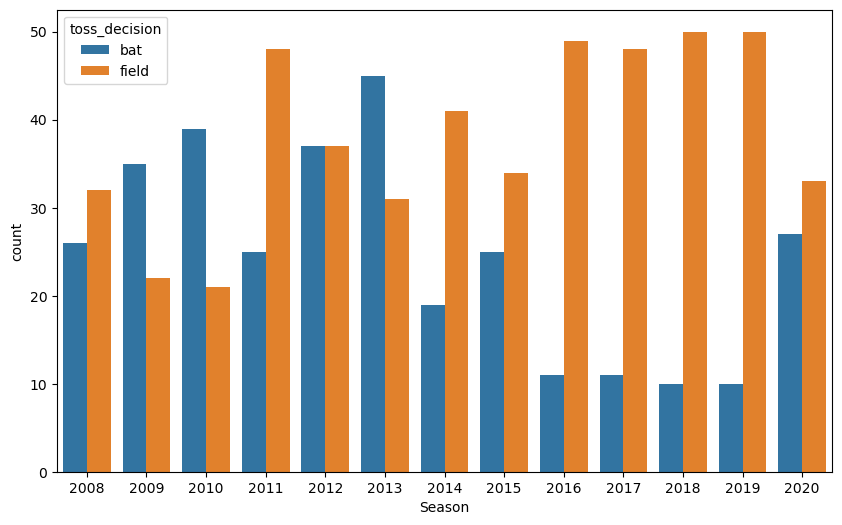

In [124]:
plt.figure(figsize=(10,6))
sns.barplot(x='Season' , y='count' , hue = 'toss_decision' , data = season_toss_count_df)

# plotting barplot of "Season" vs "count" for bat & field both

In [129]:
# Analysing if winning a toss implies winning game ?

In [137]:
match_data[['team1', 'team2' , 'toss_winner' , 'winner']]

,team1,team2,toss_winner,winner
0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,Kolkata Knight Riders
1,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,Chennai Super Kings
2,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,Delhi Daredevils
3,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,Royal Challengers Bangalore
4,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,Kolkata Knight Riders
...,...,...,...,...
811,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,Royal Challengers Bangalore
812,Mumbai Indians,Delhi Capitals,Delhi Capitals,Mumbai Indians
813,Royal Challengers Bangalore,Sunrisers Hyderabad,Sunrisers Hyderabad,Sunrisers Hyderabad
814,Delhi Capitals,Sunrisers Hyderabad,Delhi Capitals,Delhi Capitals


In [147]:
match_data['toss_win_game_win'] = np.where(match_data['toss_winner']==match_data['winner'] , 'Yes' , 'No')

In [143]:
match_data['toss_win_game_win']

0       No
1      Yes
2       No
3       No
4       No
      ... 
811     No
812     No
813    Yes
814    Yes
815     No
Name: toss_win_game_win, Length: 816, dtype: object

In [149]:
match_data['toss_win_game_win'].value_counts()

toss_win_game_win
Yes    418
No     398
Name: count, dtype: int64

In [153]:
match_data['toss_win_game_win'].value_counts().index

Index(['Yes', 'No'], dtype='object', name='toss_win_game_win')

In [151]:
match_data['toss_win_game_win'].value_counts().values

array([418, 398], dtype=int64)

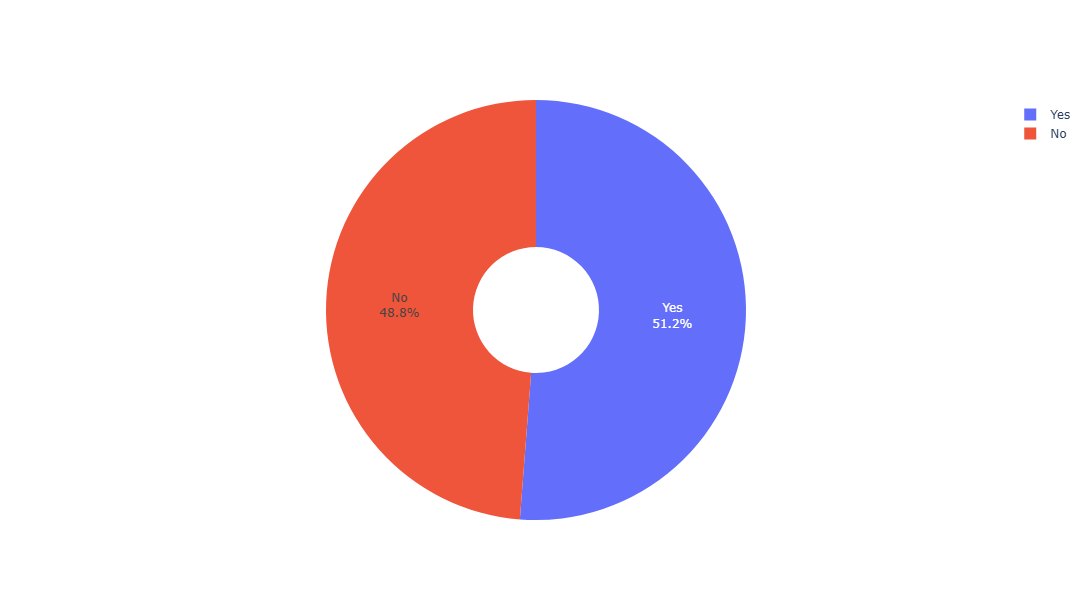

In [159]:
labels = match_data['toss_win_game_win'].value_counts().index
values = match_data['toss_win_game_win'].value_counts().values

trace = go.Pie(labels= labels , values= values , hole=0.3)
data = [trace]
fig = go.Figure(data = data)

fig.update_traces(hoverinfo='label+percent' , textinfo='label+percent')
fig.update_layout(width=600,height=600)

In [161]:
### Analysis for the number of times team have won the tournament

In [177]:
df_2018 = match_data[match_data['Season']==2018]
df_2018['winner'].tail(1).values[0]

'Chennai Super Kings'

In [179]:
winners_team ={}

for year in sorted(match_data['Season'].unique()):
    current_yr_df = match_data[match_data['Season']==year]
    winners_team[year] = current_yr_df['winner'].tail(1).values[0]

In [181]:
winners_team

{2008: 'Rajasthan Royals',
 2009: 'Deccan Chargers',
 2010: 'Chennai Super Kings',
 2011: 'Chennai Super Kings',
 2012: 'Kolkata Knight Riders',
 2013: 'Mumbai Indians',
 2014: 'Kolkata Knight Riders',
 2015: 'Mumbai Indians',
 2016: 'Sunrisers Hyderabad',
 2017: 'Mumbai Indians',
 2018: 'Chennai Super Kings',
 2019: 'Mumbai Indians',
 2020: 'Mumbai Indians'}

In [189]:
from collections import Counter
Counter(winners_team.values())

Counter({'Mumbai Indians': 5,
         'Chennai Super Kings': 3,
         'Kolkata Knight Riders': 2,
         'Rajasthan Royals': 1,
         'Deccan Chargers': 1,
         'Sunrisers Hyderabad': 1})

In [193]:
#        ***         Mumbai Indians have won the tournament most           ***

In [195]:
### Analysing for the team with most wins

In [205]:
matches_played = match_data['team1'].value_counts() + match_data['team2'].value_counts()
matches_played                   # Output is in Series

Chennai Super Kings            178
Deccan Chargers                 75
Delhi Capitals                  33
Delhi Daredevils               161
Gujarat Lions                   30
Kings XI Punjab                190
Kochi Tuskers Kerala            14
Kolkata Knight Riders          192
Mumbai Indians                 203
Pune Warriors                   46
Rajasthan Royals               161
Rising Pune Supergiant          16
Rising Pune Supergiants         14
Royal Challengers Bangalore    195
Sunrisers Hyderabad            124
Name: count, dtype: int64

In [215]:
matches_played_df = matches_played.to_frame().reset_index()
matches_played_df.columns = ['team_name' , 'Matches_played']
matches_played_df

,team_name,Matches_played
0,Chennai Super Kings,178
1,Deccan Chargers,75
2,Delhi Capitals,33
3,Delhi Daredevils,161
4,Gujarat Lions,30
5,Kings XI Punjab,190
6,Kochi Tuskers Kerala,14
7,Kolkata Knight Riders,192
8,Mumbai Indians,203
9,Pune Warriors,46


In [217]:
wins = pd.DataFrame(match_data['winner'].value_counts()).reset_index()   # total wins for each team
wins.columns = ['team_name' , 'Wins']
wins

,team_name,Wins
0,Mumbai Indians,120
1,Chennai Super Kings,106
2,Kolkata Knight Riders,99
3,Royal Challengers Bangalore,91
4,Kings XI Punjab,88
5,Rajasthan Royals,81
6,Delhi Daredevils,67
7,Sunrisers Hyderabad,66
8,Deccan Chargers,29
9,Delhi Capitals,19


In [219]:
played_vs_wins = matches_played_df.merge(wins, on='team_name' , how='inner' )
played_vs_wins

,team_name,Matches_played,Wins
0,Chennai Super Kings,178,106
1,Deccan Chargers,75,29
2,Delhi Capitals,33,19
3,Delhi Daredevils,161,67
4,Gujarat Lions,30,13
5,Kings XI Punjab,190,88
6,Kochi Tuskers Kerala,14,6
7,Kolkata Knight Riders,192,99
8,Mumbai Indians,203,120
9,Pune Warriors,46,12


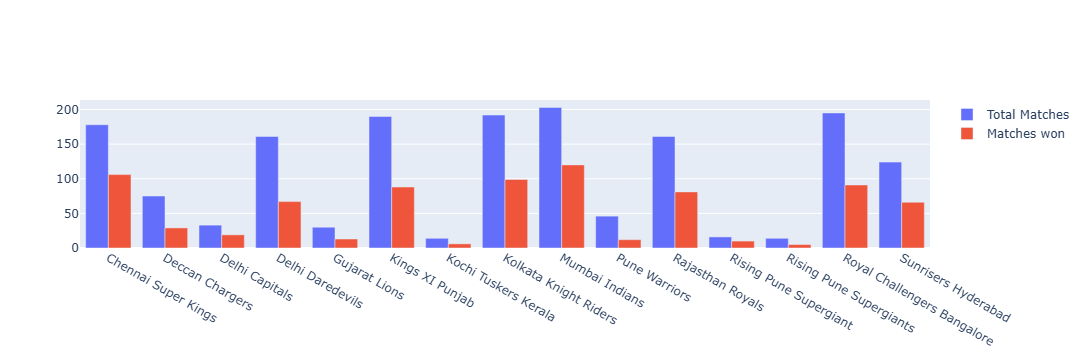

In [237]:
trace1 = go.Bar(
    x = played_vs_wins['team_name'] , 
    y = played_vs_wins['Matches_played'] , 
    name = 'Total Matches'
)


trace2 = go.Bar(
    x = played_vs_wins['team_name'] , 
    y = played_vs_wins['Wins'] , 
    name = 'Matches won'
)


iplot([trace1 , trace2])                                  # Plotting 2 different cloumns of the same df

In [233]:
###Mumbai Indians & Chennai Super Kings have more than 100 winning matches 